# Etap 5 – Analiza przeżycia (Kaplan-Meier, log-rank, regresja Coxa)

Cel: odpowiedzieć na pytanie badawcze - czy status metylacji MGMT pozostaje
niezależnym czynnikiem prognostycznym przeżycia po uwzględnieniu statusu IDH
i wieku. Dane: kohorta z bazy `db/tcga_glioma.db` (n=1044, po wykluczeniu
3 pacjentów z błędnym `os_months` – decyzja z Etapu 4).

## 1. Wczytanie i przygotowanie danych

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

DB_PATH = Path('../db/tcga_glioma.db')
conn = sqlite3.connect(DB_PATH)

query = """
SELECT p.patient_id, p.study, p.histology, p.grade, p.age_at_diagnosis,
       p.gender, p.kps, p.mutation_count,
       b.idh_status, b.mgmt_status, b.codel_1p19q,
       s.os_months, s.os_event
FROM patients p
JOIN biomarkers b ON p.patient_id = b.patient_id
JOIN survival s ON p.patient_id = s.patient_id;
"""
df = pd.read_sql_query(query, conn)

# Wykluczenie błędnych danych (Etap 4): ujemny os_months, source site QH
df = df[df['os_months'] >= 0].reset_index(drop=True)

print(df.shape)
df.head()

(1044, 13)


,patient_id,study,histology,grade,age_at_diagnosis,gender,kps,mutation_count,idh_status,mgmt_status,codel_1p19q,os_months,os_event
0,TCGA-CS-4938,LGG,astrocytoma,G2,31.0,female,90.0,15.0,Mutant,Unmethylated,non-codel,4.698251,0.0
1,TCGA-CS-4941,LGG,astrocytoma,G3,67.0,male,90.0,50.0,WT,Methylated,non-codel,7.688047,1.0
2,TCGA-CS-4942,LGG,astrocytoma,G3,44.0,female,90.0,24.0,Mutant,Unmethylated,non-codel,43.861292,1.0
3,TCGA-CS-4943,LGG,astrocytoma,G3,37.0,male,50.0,30.0,Mutant,Methylated,non-codel,18.135905,0.0
4,TCGA-CS-4944,LGG,astrocytoma,G2,50.0,male,90.0,20.0,Mutant,Methylated,non-codel,10.612133,0.0


## 2. Krzywa Kaplana-Meiera – cała kohorta

Mediana OS dla całej (zmieszanej GBM+LGG) kohorty: **20,7 miesięcy** (n=1043,
po wykluczeniu 1 pacjenta z brakiem `os_event`).

(1043, 13)


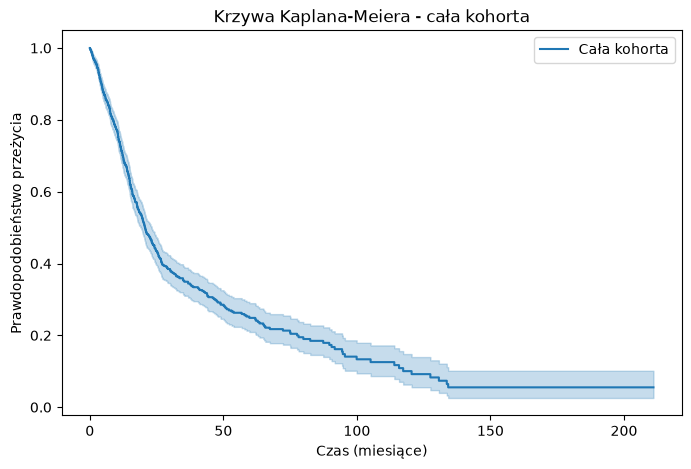

Mediana OS: 20.7 miesięcy


In [2]:
# Usunięcie 1 pacjenta z brakiem os_event (KM wymaga pełnej informacji o zdarzeniu)
df_km = df.dropna(subset=['os_event']).copy()
print(df_km.shape)

kmf = KaplanMeierFitter()
kmf.fit(durations=df_km['os_months'], event_observed=df_km['os_event'], label='Cała kohorta')

plt.figure(figsize=(8, 5))
kmf.plot_survival_function()
plt.title('Krzywa Kaplana-Meiera - cała kohorta')
plt.xlabel('Czas (miesiące)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.show()

print(f"Mediana OS: {kmf.median_survival_time_:.1f} miesięcy")

## 3. Krzywa KM wg statusu IDH

IDH mutant: mediana OS 89,7 miesięcy (n=404) vs IDH WT: 14,0 miesięcy (n=518).
Test log-rank: p=5,89e-71 – różnica wysoce istotna statystycznie. IDH jest
najsilniejszym pojedynczym czynnikiem prognostycznym w tej kohorcie.

idh_status
WT        518
Mutant    404
Name: count, dtype: int64


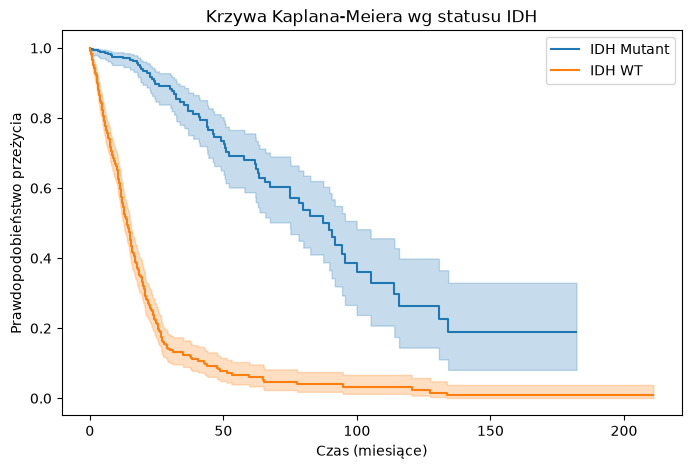

Mediana OS - Mutant: 89.7 miesięcy
Mediana OS - WT: 14.0 miesięcy

p-value (log-rank): 5.89e-71


In [3]:
# Dane tylko z znanym statusem IDH (usuwa 121 braków)
df_idh = df_km.dropna(subset=['idh_status']).copy()
print(df_idh['idh_status'].value_counts())

mutant = df_idh[df_idh['idh_status'] == 'Mutant']
wt = df_idh[df_idh['idh_status'] == 'WT']

kmf_mutant = KaplanMeierFitter()
kmf_mutant.fit(durations=mutant['os_months'], event_observed=mutant['os_event'], label='IDH Mutant')

kmf_wt = KaplanMeierFitter()
kmf_wt.fit(durations=wt['os_months'], event_observed=wt['os_event'], label='IDH WT')

plt.figure(figsize=(8, 5))
ax = kmf_mutant.plot_survival_function()
kmf_wt.plot_survival_function(ax=ax)
plt.title('Krzywa Kaplana-Meiera wg statusu IDH')
plt.xlabel('Czas (miesiące)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.show()

print(f"Mediana OS - Mutant: {kmf_mutant.median_survival_time_:.1f} miesięcy")
print(f"Mediana OS - WT: {kmf_wt.median_survival_time_:.1f} miesięcy")

# Test log-rank - czy różnica między krzywymi jest statystycznie istotna
result = logrank_test(mutant['os_months'], wt['os_months'],
                       event_observed_A=mutant['os_event'], event_observed_B=wt['os_event'])
print(f"\np-value (log-rank): {result.p_value:.2e}")

## 4. Krzywa KM wg statusu MGMT

MGMT methylated: mediana OS 50,1 miesięcy (n=558) vs unmethylated: 14,9 miesięcy
(n=300). Log-rank: p=6,10e-22 – istotne, ale efekt słabszy niż dla IDH
(przedziały ufności częściowo się nakładają).

mgmt_status
Methylated      558
Unmethylated    300
Name: count, dtype: int64


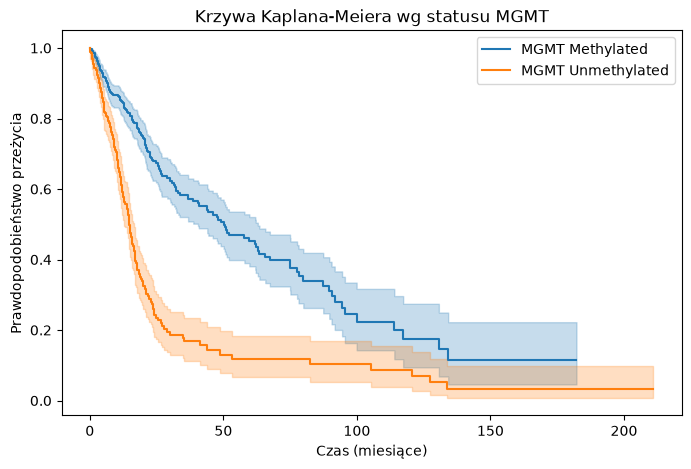

Mediana OS - Methylated: 50.1 miesięcy
Mediana OS - Unmethylated: 14.9 miesięcy

p-value (log-rank): 6.10e-22


In [4]:
# Dane tylko z znanym statusem MGMT (usuwa 185 braków)
df_mgmt = df_km.dropna(subset=['mgmt_status']).copy()
print(df_mgmt['mgmt_status'].value_counts())

methylated = df_mgmt[df_mgmt['mgmt_status'] == 'Methylated']
unmethylated = df_mgmt[df_mgmt['mgmt_status'] == 'Unmethylated']

kmf_meth = KaplanMeierFitter()
kmf_meth.fit(durations=methylated['os_months'], event_observed=methylated['os_event'], label='MGMT Methylated')

kmf_unmeth = KaplanMeierFitter()
kmf_unmeth.fit(durations=unmethylated['os_months'], event_observed=unmethylated['os_event'], label='MGMT Unmethylated')

plt.figure(figsize=(8, 5))
ax = kmf_meth.plot_survival_function()
kmf_unmeth.plot_survival_function(ax=ax)
plt.title('Krzywa Kaplana-Meiera wg statusu MGMT')
plt.xlabel('Czas (miesiące)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.show()

print(f"Mediana OS - Methylated: {kmf_meth.median_survival_time_:.1f} miesięcy")
print(f"Mediana OS - Unmethylated: {kmf_unmeth.median_survival_time_:.1f} miesięcy")

result_mgmt = logrank_test(methylated['os_months'], unmethylated['os_months'],
                            event_observed_A=methylated['os_event'], event_observed_B=unmethylated['os_event'])
print(f"\np-value (log-rank): {result_mgmt.p_value:.2e}")

grupa
Mutant / Methylated      365
WT / Unmethylated        244
WT / Methylated          167
Mutant / Unmethylated     32
Name: count, dtype: int64
Mutant / Unmethylated: mediana OS = 82.5 mies., n=32
WT / Methylated: mediana OS = 15.6 mies., n=167
Mutant / Methylated: mediana OS = 89.7 mies., n=365
WT / Unmethylated: mediana OS = 13.3 mies., n=244


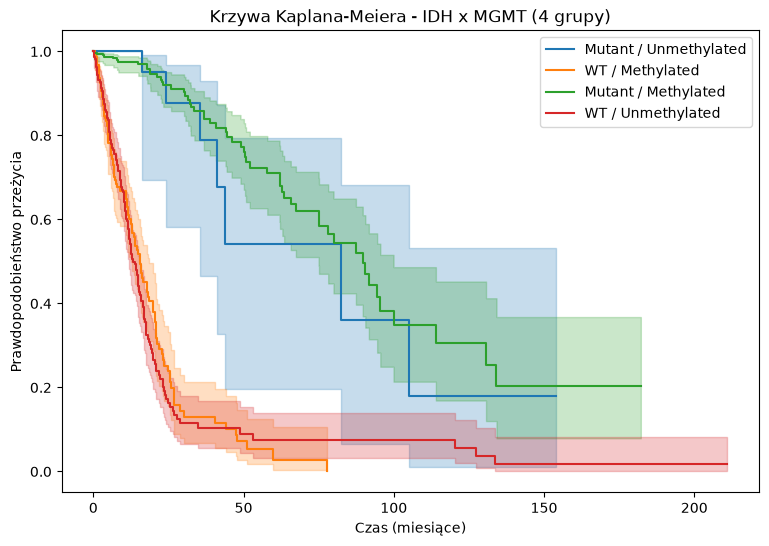

In [5]:
# Kompletne dane IDH i MGMT naraz (wykluczenie braków w obu)
df_combo = df_km.dropna(subset=['idh_status', 'mgmt_status']).copy()

# Nowa kolumna - kombinacja obu statusów
df_combo['grupa'] = df_combo['idh_status'] + ' / ' + df_combo['mgmt_status']
print(df_combo['grupa'].value_counts())

plt.figure(figsize=(9, 6))
ax = plt.subplot(111)

for grupa in df_combo['grupa'].unique():
    subset = df_combo[df_combo['grupa'] == grupa]
    kmf = KaplanMeierFitter()
    kmf.fit(durations=subset['os_months'], event_observed=subset['os_event'], label=grupa)
    kmf.plot_survival_function(ax=ax)
    print(f"{grupa}: mediana OS = {kmf.median_survival_time_:.1f} mies., n={len(subset)}")

plt.title('Krzywa Kaplana-Meiera - IDH x MGMT (4 grupy)')
plt.xlabel('Czas (miesiące)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.show()

In [7]:
# Tworzymy brakujące kolumny binarne z już wczytanych statusów tekstowych
df_km['idh_mutant'] = df_km['idh_status'].map({'Mutant': 1, 'WT': 0})
df_km['mgmt_methylated'] = df_km['mgmt_status'].map({'Methylated': 1, 'Unmethylated': 0})

cox_data = df_km.dropna(subset=['idh_mutant', 'mgmt_methylated', 'age_at_diagnosis']).copy()
print(f"n = {cox_data.shape[0]}")

n = 808


In [8]:
# Kompletne dane dla wszystkich zmiennych modelu
cox_data = df_km.dropna(subset=['idh_mutant', 'mgmt_methylated', 'age_at_diagnosis']).copy()
print(f"n = {cox_data.shape[0]}")

cph = CoxPHFitter()
cph.fit(
    cox_data[['os_months', 'os_event', 'idh_mutant', 'mgmt_methylated', 'age_at_diagnosis']],
    duration_col='os_months',
    event_col='os_event'
)

cph.print_summary()

n = 808


<lifelines.CoxPHFitter: fitted with 808 total observations, 490 right-censored observations>
             duration col = 'os_months'
                event col = 'os_event'
      baseline estimation = breslow
   number of observations = 808
number of events observed = 318
   partial log-likelihood = -1604.59
         time fit was run = 2026-07-23 12:33:48 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
idh_mutant       -1.58      0.21      0.17           -1.92           -1.24                0.15                0.29
mgmt_methylated  -0.09      0.92      0.13           -0.34            0.16                0.72                1.17
age_at_diagnosis  0.05      1.05      0.00            0.04            0.06                1.04                1.06

                  cmp to     z      p  -log2(p)
covariate                                      
idh_mutant          0.00 -9.04 <0.005     62.47
mgmt_methylated     0.00 -0.69   0.49      1.03
age_at_diagnosis    0.00  9.32 <0.005     66.20
---
Concordance = 0.82
Partial AIC = 3215.18
log-likelihood ratio test = 382.99 on 3 df
-log2(p) of ll-ratio test = 272.30